Name: Siddharth Raju Vysyaraju
CWID: 20031146

In [64]:
import pandas as pd
import numpy as np
import os
import joblib
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import RidgeClassifier  # Changed from LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

# 1. Load Data (Cluster 2)
cluster_id = 2
df = pd.read_csv('train_with_clusters.csv')
df_cluster = df[df['ClusterID'] == cluster_id].copy()
print(f"Number of samples in Cluster {cluster_id}: {len(df_cluster)}")

# 2. Separate Features & Target
X = df_cluster.drop(columns=['Index', 'Bankrupt?', 'ClusterID'])
y = df_cluster['Bankrupt?']

# 3. Feature Selection
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.feature_selection")
warnings.filterwarnings("ignore", category=RuntimeWarning, module="sklearn.feature_selection")
constant_cols = [col for col in X.columns if X[col].nunique() == 1]
if constant_cols:
    print(f"Constant features removed before selection: {constant_cols}")
selector = SelectKBest(score_func=f_classif, k=25)
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]
X = X[selected_features]
print(f"Selected top 25 features: {list(selected_features)}")

# 4. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Apply SMOTE
print("Applying SMOTE to balance classes...")
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)
print("Resampled class distribution:")
print(pd.Series(y_resampled).value_counts())

# 6. Define Base Models
base_models = [
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('svm', SVC(probability=True, kernel='rbf', random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
]

# 7. Train Base Models and Evaluate
tt_total = 0
tf_total = 0
fitted_base_models = []
print("\n Base Model Evaluation (on resampled data):")
for name, model in base_models:
    model.fit(X_resampled, y_resampled)
    y_pred_base = model.predict(X_scaled)
    tt_curr = np.sum((y == 1) & (y_pred_base == 1))
    tf_curr = np.sum((y == 1) & (y_pred_base == 0))
    acc_curr = tt_curr / (tt_curr + tf_curr) if (tt_curr + tf_curr) > 0 else 0
    tt_total += tt_curr
    tf_total += tf_curr
    fitted_base_models.append((name, model))
    print(f"Base model '{name}': accuracy={acc_curr:.2f} [{tt_curr}({tf_curr})]")

total_acc = tt_total / (tt_total + tf_total) if (tt_total + tf_total) > 0 else 0
print(f"\nTotal Base Model Accuracy: {total_acc:.2f} [{tt_total}({tf_total})]")

# 8. Train Stacking Model with RidgeClassifier
stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=RidgeClassifier(),  # ← Updated here
    cv=5
)
stack_model.fit(X_resampled, y_resampled)

# 9. Evaluate Stacking Model
y_pred_stack = stack_model.predict(X_scaled)
stack_acc = accuracy_score(y, y_pred_stack)
print("\nStacking Model Accuracy on Resampled Data:", stack_acc)
print("Classification Report:\n", classification_report(y, y_pred_stack, zero_division=0))

# 10. Save Model Artifacts
output_dir = f'cluster{cluster_id}_output'
os.makedirs(output_dir, exist_ok=True)
joblib.dump(stack_model, f'{output_dir}/stacked_model_cluster{cluster_id}.pkl')
joblib.dump(scaler, f'{output_dir}/scaler_cluster{cluster_id}.pkl')
with open(f'{output_dir}/selected_features_cluster{cluster_id}.txt', 'w') as f:
    for feat in selected_features:
        f.write(f"{feat}\n")

print(f"\nModel, scaler, and feature list saved in '{output_dir}/'")

Number of samples in Cluster 2: 1763
Constant features removed before selection: ['Liability-Assets_Flag', 'Net_Income_Flag']
Selected top 25 features: ['ROA(C)_before_interest_and_depreciation_before_interest', 'ROA(A)_before_interest_and_%_after_tax', 'ROA(B)_before_interest_and_depreciation_after_tax', 'Net_Value_Per_Share_(B)', 'Net_Value_Per_Share_(A)', 'Net_Value_Per_Share_(C)', 'Persistent_EPS_in_the_Last_Four_Seasons', 'Per_Share_Net_profit_before_tax_(Yuan_¥)', 'Total_debt/Total_net_worth', 'Debt_ratio_%', 'Net_worth/Assets', 'Borrowing_dependency', 'Net_profit_before_tax/Paid-in_capital', 'Inventory_and_accounts_receivable/Net_value', 'Working_Capital_to_Total_Assets', 'Current_Liability_to_Assets', 'Working_Capital/Equity', 'Current_Liabilities/Equity', 'Retained_Earnings_to_Total_Assets', 'Current_Liability_to_Equity', 'Equity_to_Long-term_Liability', 'Net_Income_to_Total_Assets', "Net_Income_to_Stockholder's_Equity", 'Liability_to_Equity', 'Equity_to_Liability']
Applying S


Confusion Matrices for Base Models (Cluster 2):
Base model 'knn': accuracy=1.00 [82(0)]
Base model 'svm': accuracy=0.90 [74(8)]
Base model 'rf': accuracy=1.00 [82(0)]

Total Base Model Accuracy (Cluster 2): 0.97 [238(8)]


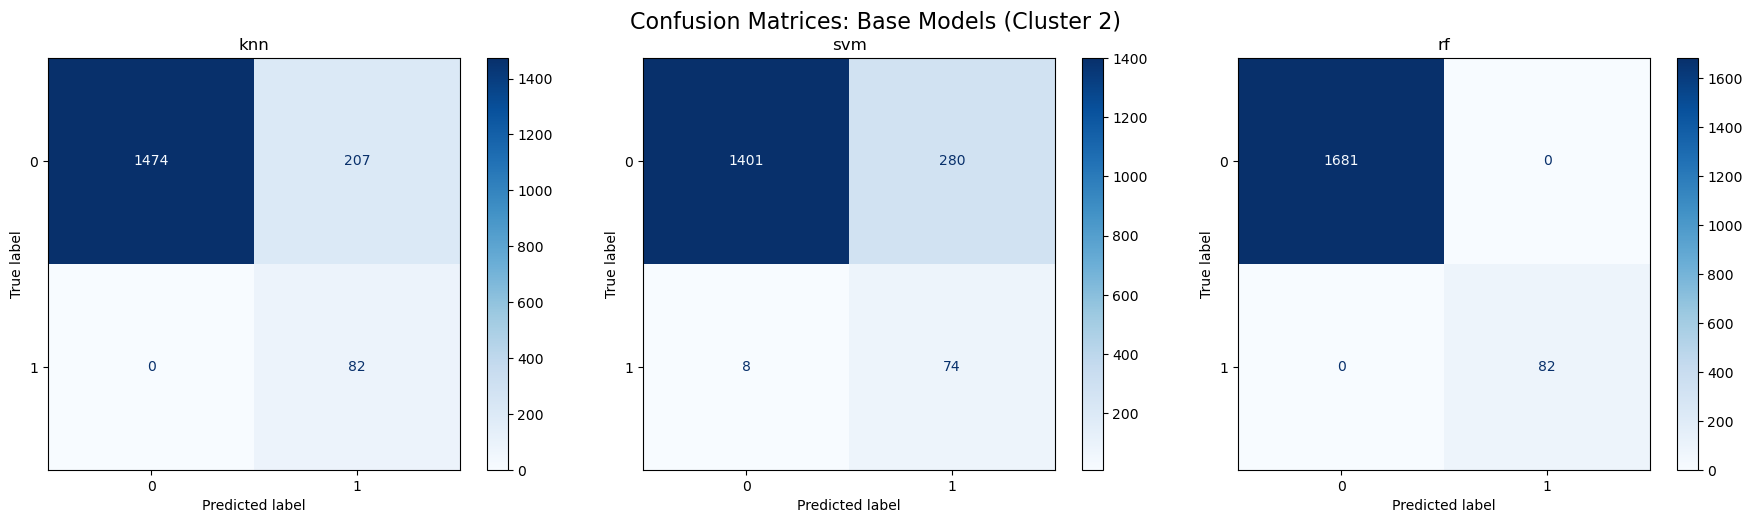


Meta Model (Stacking) - Cluster 2: accuracy=1.00 [82(0)]


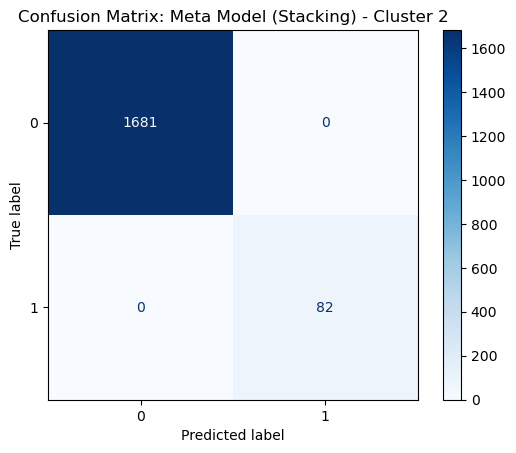


Meta Model Classification Report:
                  precision    recall  f1-score   support

Not Bankrupt (0)       1.00      1.00      1.00      1681
    Bankrupt (1)       1.00      1.00      1.00        82

        accuracy                           1.00      1763
       macro avg       1.00      1.00      1.00      1763
    weighted avg       1.00      1.00      1.00      1763



In [68]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Suppress common ML warnings
warnings.filterwarnings("ignore")

# Use the right cluster_id
cluster_id = 2

# 1. Base Models Evaluation
tt_total = 0
tf_total = 0
pred_base = {}

print(f"\nConfusion Matrices for Base Models (Cluster {cluster_id}):")
num_cols = len(fitted_base_models)
fig, axes = plt.subplots(1, num_cols, figsize=(6 * num_cols, 5))
axes = axes.flatten()

for i, (name, model) in enumerate(fitted_base_models):
    y_pred = model.predict(X_scaled)
    pred_base[name] = y_pred

    tt_curr = np.sum((y == 1) & (y_pred == 1))
    tf_curr = np.sum((y == 1) & (y_pred == 0))
    acc_curr = tt_curr / (tt_curr + tf_curr) if (tt_curr + tf_curr) > 0 else 0

    tt_total += tt_curr
    tf_total += tf_curr

    print(f"Base model '{name}': accuracy={acc_curr:.2f} [{tt_curr}({tf_curr})]")

    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name}')

total_acc = tt_total / (tt_total + tf_total) if (tt_total + tf_total) > 0 else 0
print(f"\nTotal Base Model Accuracy (Cluster {cluster_id}): {total_acc:.2f} [{tt_total}({tf_total})]")

plt.suptitle(f'Confusion Matrices: Base Models (Cluster {cluster_id})', fontsize=16)
plt.tight_layout()
plt.show()

# 2. Stacking Model Evaluation
y_pred_stack = stack_model.predict(X_scaled)

tt_meta = np.sum((y == 1) & (y_pred_stack == 1))
tf_meta = np.sum((y == 1) & (y_pred_stack == 0))
acc_meta = tt_meta / (tf_meta + tt_meta) if (tf_meta + tt_meta) > 0 else 0

print(f"\nMeta Model (Stacking) - Cluster {cluster_id}: accuracy={acc_meta:.2f} [{tt_meta}({tf_meta})]")

cm_stack = confusion_matrix(y, y_pred_stack)
disp_stack = ConfusionMatrixDisplay(confusion_matrix=cm_stack, display_labels=[0, 1])
disp_stack.plot(cmap='Blues')
plt.title(f'Confusion Matrix: Meta Model (Stacking) - Cluster {cluster_id}')
plt.show()

print("\nMeta Model Classification Report:")
print(classification_report(y, y_pred_stack, target_names=["Not Bankrupt (0)", "Bankrupt (1)"], zero_division=0))